In [1]:
import glob
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
np.set_printoptions(precision=3, suppress=True)

In [2]:
def mosaic_fits(input_files, output_wcs, output_shape, output_file):
    """
    将若干 GALFA FITS（轴顺序: (v, y, x) = (VELO, DEC, RA)）拼接到同一输出网格上。
    重叠区域处理：sum_map 累加、count_map 计数，最后 output_data = sum_map / count_map。

    设计目标：切片范围计算尽量清晰，不做“反向计算验证”闭环。
    假设：
      - 各 FITS 与 output_wcs 具有相同的投影/像素尺度/旋转（只存在平移）
      - FITS 尺寸固定为 512×512，且 header 中 CRPIX=256.5/256.5（像素中心半整数）
      - 数据中无 NaN/BLANK（全部像素有效）
    """

    output_data = np.zeros(output_shape, dtype=np.float32)
    sum_map = np.zeros(output_shape, dtype=np.float32)
    count_map = np.zeros(output_shape, dtype=np.uint16)

    ny_total, nx_total = output_shape[1], output_shape[2]
    output_wcs_2d = output_wcs.celestial

    # round-half-up：避免 np.round 在 0.5 附近的银行家取整导致的 ±1 抖动
    def round_half_up(x):
        return np.floor(x + 0.5)

    for file in input_files:
        print("处理:", file)
        hdul = fits.open(file, memmap=False)
        header = hdul[0].header
        wcs = WCS(header)
        wcs_2d = wcs.celestial

        nx = int(header["NAXIS1"])
        ny = int(header["NAXIS2"])
        data = hdul[0].data  # 已经转换为 float32/float64 的物理量；下面强制 float32

        # ---- 1) 用 FITS 的参考点（CRPIX/CRVAL）计算它在输出图上的平移位置 ----
        # CRPIX 是 FITS 1-based；wcs 接口 origin=0 用 0-based，因此要 -1
        x_ref_in = float(header["CRPIX1"] - 1.0)  # 255.5
        y_ref_in = float(header["CRPIX2"] - 1.0)  # 255.5
        # print(f"输入 FITS 的参考点在输入像素坐标系中的位置: ({x_ref_in}, {y_ref_in})")

        # 参考点世界坐标（直接来自 header 的 CRVAL1/2 最清晰）
        ra_ref = float(header["CRVAL1"])
        dec_ref = float(header["CRVAL2"])
        # print(f"输入 FITS 的参考点的世界坐标: ({ra_ref}, {dec_ref})")

        # 映射到输出像素坐标（0-based，浮点；常见会带 .5）
        x_ref_out, y_ref_out = output_wcs_2d.wcs_world2pix(ra_ref, dec_ref, 0)
        # print(f"输入 FITS 的参考点在输出像素坐标系中的位置: ({x_ref_out}, {y_ref_out})")

        # FITS 左下角（输入像素 0,0）在输出中的起点：
        # x0_out_f = x_ref_out - x_ref_in  （因为输入参考点在 FITS 内的像素坐标是 x_ref_in）
        x0_out = round_half_up(x_ref_out - x_ref_in)
        y0_out = round_half_up(y_ref_out - y_ref_in)
        # print(f"输入 FITS 的左下角在输出像素坐标系中的位置: ({x0_out}, {y0_out})")

        # 未裁剪的输出切片（右开）
        xs_out = slice(x0_out, x0_out + nx)
        ys_out = slice(y0_out, y0_out + ny)
        # print(f"未裁剪的输出切片: {xs_out}, {ys_out}")

        # ---- 2) 裁剪到输出边界，并同步得到输入切片（纯整数，不需要反向 WCS）----
        cut_left = max(0, -xs_out.start)
        cut_bottom = max(0, -ys_out.start)
        cut_right = max(0, xs_out.stop - nx_total)
        cut_top = max(0, ys_out.stop - ny_total)

        xs_out = slice(xs_out.start + cut_left, xs_out.stop - cut_right)
        ys_out = slice(ys_out.start + cut_bottom, ys_out.stop - cut_top)
        # print(f"裁剪后的输出切片: {xs_out}, {ys_out}")

        xs_in = slice(0 + cut_left, nx - cut_right)
        ys_in = slice(0 + cut_bottom, ny - cut_top)
        # print(f"裁剪后的输入切片: {xs_in}, {ys_in}")

        # 打印切片信息
        xs_out = slice(int(xs_out.start), int(xs_out.stop))
        ys_out = slice(int(ys_out.start), int(ys_out.stop))
        xs_in = slice(int(xs_in.start), int(xs_in.stop))
        ys_in = slice(int(ys_in.start), int(ys_in.stop))

        # print(f"最终在输出图像中的切片: {xs_out}, {ys_out}")
        # print(f"最终在输入图像中的切片: {xs_in}, {ys_in}", "\n")

        # ---- 3) 累加/计数（重叠区域自然会被加多次，最后除以次数即平均）----
        slab = data[:, ys_in, xs_in].astype(np.float32, copy=False)
        sum_map[:, ys_out, xs_out] += slab
        count_map[:, ys_out, xs_out] += np.uint16(1)

        hdul.close()

    # ---- 4) 输出平均值 ----
    output_data = sum_map / count_map

    # ---- 5) 写入输出 FITS ----
    output_header = output_wcs.to_header()
    output_header["NAXIS"] = 3
    output_header["NAXIS1"] = output_shape[2]
    output_header["NAXIS2"] = output_shape[1]
    output_header["NAXIS3"] = output_shape[0]
    output_header["BUNIT"] = "K"
    output_header["OBSFREQ"] = 1.4204058e+9

    fits.writeto(output_file, output_data, header=output_header, overwrite=True)
    # print(f"处理完成，文件名为 {output_file}\n")

In [3]:
fits_file_list = sorted(glob.glob('./*_N.fits'))
fits_file_list

['./GALFA_HI_RA+DEC_012.00+26.35_N.fits',
 './GALFA_HI_RA+DEC_012.00+34.35_N.fits',
 './GALFA_HI_RA+DEC_020.00+26.35_N.fits',
 './GALFA_HI_RA+DEC_020.00+34.35_N.fits',
 './GALFA_HI_RA+DEC_028.00+26.35_N.fits',
 './GALFA_HI_RA+DEC_028.00+34.35_N.fits',
 './GALFA_HI_RA+DEC_036.00+26.35_N.fits',
 './GALFA_HI_RA+DEC_036.00+34.35_N.fits',
 './GALFA_HI_RA+DEC_044.00+26.35_N.fits',
 './GALFA_HI_RA+DEC_044.00+34.35_N.fits',
 './GALFA_HI_RA+DEC_052.00+26.35_N.fits',
 './GALFA_HI_RA+DEC_052.00+34.35_N.fits',
 './GALFA_HI_RA+DEC_060.00+26.35_N.fits',
 './GALFA_HI_RA+DEC_060.00+34.35_N.fits',
 './GALFA_HI_RA+DEC_068.00+26.35_N.fits',
 './GALFA_HI_RA+DEC_068.00+34.35_N.fits',
 './GALFA_HI_RA+DEC_076.00+26.35_N.fits',
 './GALFA_HI_RA+DEC_076.00+34.35_N.fits',
 './GALFA_HI_RA+DEC_084.00+26.35_N.fits',
 './GALFA_HI_RA+DEC_084.00+34.35_N.fits',
 './GALFA_HI_RA+DEC_092.00+26.35_N.fits',
 './GALFA_HI_RA+DEC_092.00+34.35_N.fits']

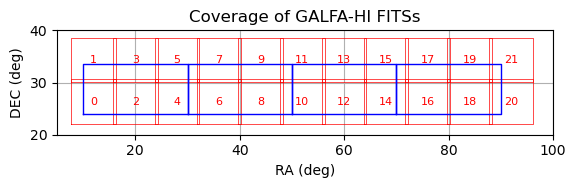

In [4]:
# 绘制每个图的覆盖图

x_start = [7.741658, 15.741658, 23.741658, 31.741658, 39.741658, 47.741658, 55.741658, 63.741658, 71.741658, 79.741658, 87.741658]
x_end = [16.258342, 24.258342, 32.258342, 40.258342, 48.258342, 56.258342, 64.258342, 72.258342, 80.258342, 88.258342, 96.258342]

x_output_start = [10, 30, 50, 70]
x_output_end = [30, 50, 70, 90]

import matplotlib.pyplot as plt

plt.figure()
# 每个方形取横坐标为 x_start[i] 到 x_end[i]，纵坐标交替取 22.091658 deg - 30.608342 deg 和 30.091658 deg - 38.608342 deg
# 并标注编号顺序，按x和y从小到大排列，写在方形的中间
for i in range(len(x_start)):
    plt.plot([x_start[i], x_end[i], x_end[i], x_start[i], x_start[i]], [22.091658, 22.091658, 30.608342, 30.608342, 22.091658], 'r-', linewidth=0.5)
    plt.plot([x_start[i], x_end[i], x_end[i], x_start[i], x_start[i]], [30.091658, 30.091658, 38.608342, 38.608342, 30.091658], 'r-', linewidth=0.5)
    plt.text((x_start[i] + x_end[i]) / 2, 26.35, str(i*2), color='r', fontsize=8, ha='center', va='center')
    plt.text((x_start[i] + x_end[i]) / 2, 34.35, str(i*2+1), color='r', fontsize=8, ha='center', va='center')
# 每个方形取横坐标为 x_output_start[i] 到 x_output_end[i]，纵坐标取 24 deg - 33.5 deg
for i in range(len(x_output_start)):
    plt.plot([x_output_start[i], x_output_end[i], x_output_end[i], x_output_start[i], x_output_start[i]], [24, 24, 33.5, 33.5, 24], 'b-', linewidth=1)
plt.xlabel('RA (deg)')
plt.ylabel('DEC (deg)')
plt.title('Coverage of GALFA-HI FITSs')
plt.xlim(5, 100)
plt.ylim(20, 40)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid()
plt.show()

In [5]:
input_files_list = [fits_file_list[0:6], fits_file_list[4:12], fits_file_list[10:16], fits_file_list[14:22]]
output_file_list = ["./Combined/GALFA_RA10_30_DEC24_33.fits", "./Combined/GALFA_RA30_50_DEC24_33.fits", "./Combined/GALFA_RA50_70_DEC24_33.fits", "./Combined/GALFA_RA70_90_DEC24_33.fits"]

for i in range(len(input_files_list)):
    input_files = input_files_list[i]
    print(f"处理第 {i} 组文件")

    ra_min, ra_max = x_output_start[i], x_output_end[i]
    dec_min, dec_max = 24.0, 33.5

    output_file = output_file_list[i]

    # 读取参考 header/WCS
    with fits.open(input_files[0], memmap=False, do_not_scale_image_data=True) as hdul0:
        header0 = hdul0[0].header
        wcs0 = WCS(header0)

    NAXIS3 = header0["NAXIS3"]
    CDELT1 = header0["CDELT1"]
    CDELT2 = header0["CDELT2"]

    nx_total = int(np.round((ra_max - ra_min) / abs(CDELT1)))
    ny_total = int(np.round((dec_max - dec_min) / abs(CDELT2)))
    output_shape = (NAXIS3, ny_total, nx_total)  # (v, y, x)
    print(f"输出图像的尺寸 (v, y, x): {output_shape}")

    # 构造输出WCS（与源一致，只锚定到目标范围）
    output_wcs = wcs0.deepcopy()
    output_wcs.wcs.crpix[0] = 0.5
    output_wcs.wcs.crpix[1] = 0.5 - dec_min / CDELT2  # 使得 dec_min 落在像素中心
    output_wcs.wcs.crval[0] = ra_max
    output_wcs.wcs.crval[1] = 0
    output_wcs.wcs.cdelt[0] = CDELT1
    output_wcs.wcs.cdelt[1] = CDELT2

    # 只取天球2D WCS 做像素框映射
    output_wcs_2d = output_wcs.celestial
    print("输出图像的 WCS:", output_wcs_2d)

    mosaic_fits(input_files=input_files, output_wcs=output_wcs, output_shape=output_shape, output_file=output_file)
    print(f"处理完成，文件名为 {output_file}\n")

处理第 0 组文件
输出图像的尺寸 (v, y, x): (2048, 570, 1200)
输出图像的 WCS: WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---CAR' 'DEC--CAR'
CUNIT : 'deg' 'deg'
CRVAL : 30.0 0.0
CRPIX : 0.5 -1439.5
NAXIS : 512  512
处理: ./GALFA_HI_RA+DEC_012.00+26.35_N.fits
处理: ./GALFA_HI_RA+DEC_012.00+34.35_N.fits
处理: ./GALFA_HI_RA+DEC_020.00+26.35_N.fits
处理: ./GALFA_HI_RA+DEC_020.00+34.35_N.fits
处理: ./GALFA_HI_RA+DEC_028.00+26.35_N.fits
处理: ./GALFA_HI_RA+DEC_028.00+34.35_N.fits
处理完成，文件名为 ./Combined/GALFA_RA10_30_DEC24_33.fits

处理第 1 组文件
输出图像的尺寸 (v, y, x): (2048, 570, 1200)
输出图像的 WCS: WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---CAR' 'DEC--CAR'
CUNIT : 'deg' 'deg'
CRVAL : 50.0 0.0
CRPIX : 0.5 -1439.5
NAXIS : 512  512
处理: ./GALFA_HI_RA+DEC_028.00+26.35_N.fits
处理: ./GALFA_HI_RA+DEC_028.00+34.35_N.fits
处理: ./GALFA_HI_RA+DEC_036.00+26.35_N.fits
处理: ./GALFA_HI_RA+DEC_036.00+34.35_N.fits
处理: ./GALFA_HI_RA+DEC_044.00+26.35_N.fits
处理: ./GALFA_HI_RA+DEC_044.00+34.35_N.fits
处理: ./GALFA_HI_RA+DEC_052.00+26.35_N.fits
处理: ./GA